# Email spam classification with BERT and GPT-2

## 1.Download data
Download data from kaggle, and then unzip it.

The folder structure is for google colab, modify it if needed.

In [1]:
import os

filepath = "/content/emails-for-spam-or-ham-classification-trec-2007.zip"
url = "https://www.kaggle.com/api/v1/datasets/download/bayes2003/emails-for-spam-or-ham-classification-trec-2007"

if os.path.exists(filepath):
    print(f"{filepath} already exists, skipping download.")
else:
    print(f"{filepath} not found, proceed to download or process.")
    !curl -L -o {filepath} {url}
    !unzip {filepath}



/content/emails-for-spam-or-ham-classification-trec-2007.zip already exists, skipping download.


## 2.Install libs

In [2]:
import importlib.util
import sys
import subprocess

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("torch", "torch")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("nltk", "nltk")
install_if_missing("sentence-transformers", "sentence_transformers")
install_if_missing("torchviz", "torchviz")
install_if_missing("datasets", "datasets")

torch is already installed.
scikit-learn is already installed.
nltk is already installed.
sentence-transformers is already installed.
torchviz is already installed.
datasets is already installed.


## 3.Import libs and functions

In [3]:
import os
import glob
import re
import pandas as pd
import re
import string
import numpy as np

import nltk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from transformers import BertModel, BertTokenizer
from transformers import GPT2Tokenizer, GPT2Model
from transformers import GPT2ForSequenceClassification
from transformers import Trainer
from transformers import TrainingArguments

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,precision_recall_fscore_support
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt

## 4.Download common words

In [4]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 5.Read email dataset

In [5]:
df = pd.read_csv(r'email_text.csv')
df.head()

,label,text
0,1,do you feel the pressure to perform and not ri...
1,0,hi i've just updated from the gulus and i chec...
2,1,mega authenticv i a g r a discount pricec i a ...
3,1,hey billy it was really fun going out the othe...
4,1,system of the home it will have the capabiliti...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53668 entries, 0 to 53667
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   53668 non-null  int64 
 1   text    53668 non-null  object
dtypes: int64(1), object(1)
memory usage: 838.7+ KB


## 6.Show percentage of ham and spam

Considering the data size difference between ham and spam is not too much, so we will not do dataset balancing operation here

In [7]:
df.label.value_counts(normalize=True)

,proportion
label,
1,0.557558
0,0.442442


In [8]:
df.label.value_counts()

,count
label,
1,29923
0,23745


## 7.Define cleaner function and pre processing

In [9]:
def text_cleaner(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'m", " am", text)

    text = re.sub(r'[^\w\s]', '', text)

    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_text = [word for word in tokens if word.lower() not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

    cleaned_text = ' '.join(lemmatized_text)

    return cleaned_text

In [10]:
df['cleaned_text'] = df['text'].apply(text_cleaner)
df.head()

,label,text,cleaned_text
0,1,do you feel the pressure to perform and not ri...,feel pressure perform rising occasion try v ia...
1,0,hi i've just updated from the gulus and i chec...,hi updated gulu check mirror seems little typo...
2,1,mega authenticv i a g r a discount pricec i a ...,mega authenticv g r discount pricec l discount...
3,1,hey billy it was really fun going out the othe...,hey billy really fun going night talking said ...
4,1,system of the home it will have the capabiliti...,system home capability linked far know within ...


## 9.Base model to compare(BERT)

In [11]:
model_name = 'sentence-transformers/bert-base-nli-mean-tokens'
tokenizer = BertTokenizer.from_pretrained(model_name)
epoch_num = 20

### 9.1 Define SpamClassifier class

In [12]:
class SpamClassifier_bert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.2):
        super(SpamClassifier_bert, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

### 9.2.set up train and test datasets

In [13]:
model = SentenceTransformer(model_name)
embeddings = model.encode(df['cleaned_text'].tolist())
target = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, target, test_size=0.2, random_state=42)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### 9.3. Define model parameters

In [16]:
input_size = embeddings.shape[1]
hidden_size = 256
output_size = 1

In [17]:
model = SpamClassifier_bert(input_size, hidden_size, output_size)

In [18]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

### 9.4. Training

In [19]:
train_losses = []
test_losses = []

test_preds = []
test_labels = []

test_accuracies = []
test_precisions = []
test_recalls = []
test_f1s = []


for epoch in range(epoch_num):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        labels = labels.unsqueeze(1).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        predicted_train = (outputs > 0.5).float()
        correct_train += (predicted_train == labels).sum().item()
        total_train += labels.size(0)

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            labels = labels.unsqueeze(1).float()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            predicted_test = (outputs > 0.5).float()
            correct_test += (predicted_test == labels).sum().item()
            total_test += labels.size(0)

            test_preds.extend(predicted_test.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_losses.append(test_loss / len(test_loader))

    test_accuracies.append(accuracy_score(test_labels, test_preds))
    test_precisions.append(precision_score(test_labels, test_preds))
    test_recalls.append(recall_score(test_labels, test_preds))
    test_f1s.append(f1_score(test_labels, test_preds))


    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Test Loss: #{test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}, Test Precision: {test_precisions[-1]},  Test Recall: {test_recalls[-1]}, Test F1: {test_f1s[-1]}")

Epoch 1, Train Loss: 0.14189685715276376, Test Loss: #0.10593431599027965, Test Accuracy: 0.9645984721445873, Test Precision: 0.9668397253391392,  Test Recall: 0.9694374475230898, Test F1: 0.968136843870535
Epoch 2, Train Loss: 0.09820833573521749, Test Loss: #0.09071467946549612, Test Accuracy: 0.9673001676914478, Test Precision: 0.969032474054235,  Test Recall: 0.9721242653232578, Test F1: 0.9705759074524268
Epoch 3, Train Loss: 0.08100329888686149, Test Loss: #0.0793302161702221, Test Accuracy: 0.9691012980560214, Test Precision: 0.9696547884187082,  Test Recall: 0.9748110831234257, Test F1: 0.9722260990928123
Epoch 4, Train Loss: 0.0706608976103364, Test Loss: #0.07291870478296741, Test Accuracy: 0.9710033538289548, Test Precision: 0.9719446418865242,  Test Recall: 0.975902602854744, Test F1: 0.9739196011479565
Epoch 5, Train Loss: 0.06469404207120598, Test Loss: #0.07677716281129203, Test Accuracy: 0.9722191168250419, Test Precision: 0.9725340817963112,  Test Recall: 0.97753148614

In [20]:
# Find the index (epoch) with the lowest test loss
min_loss_idx = test_losses.index(min(test_losses))
min_epoch = min_loss_idx + 1
min_test_loss = test_losses[min_loss_idx]
corresponding_train_loss = train_losses[min_loss_idx]
corresponding_test_acc = test_accuracies[min_loss_idx]
corresponding_test_precision = test_precisions[min_loss_idx]
corresponding_test_recall = test_recalls[min_loss_idx]
corresponding_test_f1 = test_f1s[min_loss_idx]

# Print the values
print(f"Epoch with minimum test loss: {min_epoch}")
print(f"Train Loss: {corresponding_train_loss:.4f}")
print(f"Test Loss: {min_test_loss:.4f}")
print(f"Test Accuracy: {corresponding_test_acc:.4f}")
print(f"Test Precision: {corresponding_test_precision:.4f}")
print(f"Test Recall: {corresponding_test_recall:.4f}")
print(f"Test F1: {corresponding_test_f1:.4f}")

Epoch with minimum test loss: 11
Train Loss: 0.0379
Test Loss: 0.0644
Test Accuracy: 0.9761
Test Precision: 0.9758
Test Recall: 0.9814
Test F1: 0.9786


### 9.5. Plot Losses and Accuracies

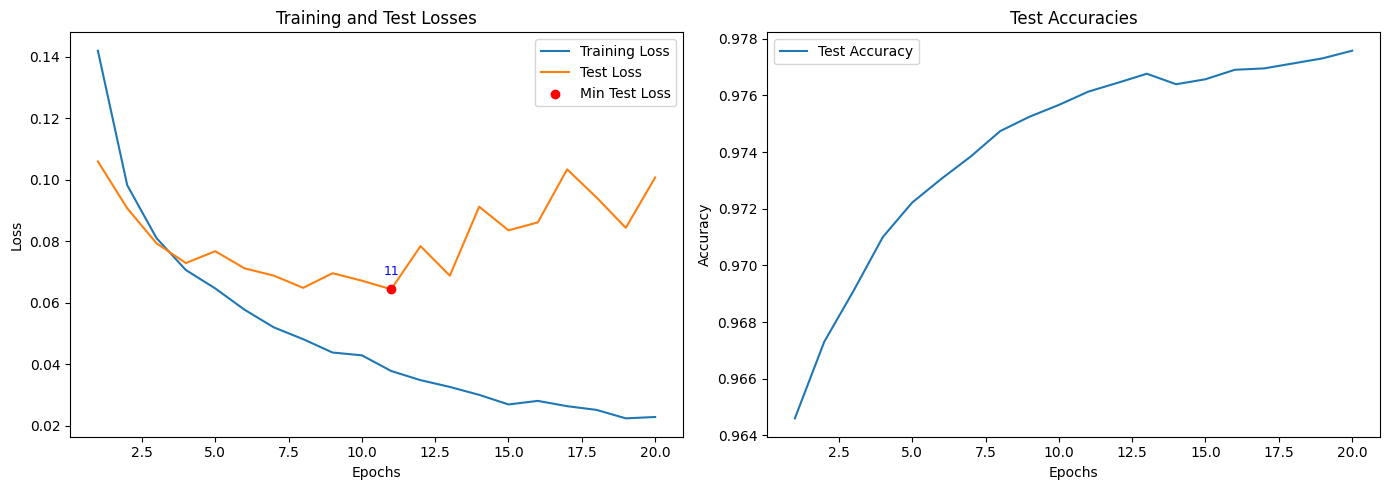

In [21]:
plt.figure(figsize=(14, 10))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epoch_num + 1), train_losses, label='Training Loss')
plt.plot(range(1, epoch_num + 1), test_losses, label='Test Loss')
plt.scatter(min_epoch, min_test_loss, color='red', label='Min Test Loss', zorder=5)
plt.annotate(f'{min_epoch}',
             (min_epoch, min_test_loss),
             textcoords="offset points",
             xytext=(0,10),
             ha='center',
             color='blue',
             fontsize=9)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epoch_num + 1), test_accuracies, label='Test Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

## 10.Model to compare(GPT-2)

In [22]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels=2  # Binary classification
)
model.config.pad_token_id = tokenizer.pad_token_id

epoch_num = 20

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 10.1 Define SpamClassifier class

In [23]:
class SpamClassifier_gpt2(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(texts, padding="max_length", truncation=True, max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

### 10.2 setup train and test datasets

In [24]:
# Tokenize function
def tokenize(example):
    return tokenizer(
        example['cleaned_text'],
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

# Prepare dataset
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["cleaned_text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_dataset = SpamClassifier_gpt2(train_texts, train_labels, tokenizer)
test_dataset = SpamClassifier_gpt2(test_texts, test_labels, tokenizer)

### 10.3 define extra functions

In [25]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### 10.4 Training

In [26]:
training_args = TrainingArguments(
    output_dir="./gpt2-spam",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs = epoch_num,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    gradient_accumulation_steps = 2,
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics = compute_metrics
)

trainer.train()

<ipython-input-26-1725572347>:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.124800,0.050699,0.985001,0.990731,0.982289,0.986492
2,0.032700,0.031714,0.991243,0.991818,0.992481,0.992150
3,0.015200,0.031898,0.992733,0.991840,0.995155,0.993495
4,0.009500,0.041999,0.991988,0.991338,0.994319,0.992826
5,0.005900,0.047678,0.993758,0.992838,0.995990,0.994412
6,0.005700,0.050229,0.992081,0.989545,0.996324,0.992923
7,0.002800,0.050945,0.991895,0.993639,0.991813,0.992725
8,0.002800,0.059472,0.991429,0.991329,0.993317,0.992322
9,0.002200,0.074538,0.988541,0.995101,0.984294,0.989668
10,0.002100,0.058334,0.992547,0.994142,0.992481,0.993311


TrainOutput(global_step=6720, training_loss=0.010729007986152455, metrics={'train_runtime': 1593.9422, 'train_samples_per_second': 538.715, 'train_steps_per_second': 4.216, 'total_flos': 5.609257344958464e+16, 'train_loss': 0.010729007986152455, 'epoch': 20.0})

### 10.5. Plot Losses and Accuracies

In [27]:
logs = trainer.state.log_history

# Convert to DataFrame
log_df = pd.DataFrame(logs)
# Filter for loss and epoch info
loss_df = log_df[['epoch', 'loss', 'eval_loss','eval_accuracy','eval_precision','eval_recall','eval_f1']].dropna(how='all')

# Group by epoch and aggregate by 'first non-null'
merged_df = log_df.groupby('epoch').agg({
    'loss': 'first',
    'eval_loss': 'first',
    'eval_accuracy': 'first',
    'eval_precision': 'first',
    'eval_recall': 'first',
    'eval_f1': 'first'
}).reset_index()

# Show merged result
print(merged_df)

    epoch    loss  eval_loss  eval_accuracy  eval_precision  eval_recall  \
0     1.0  0.1248   0.050699       0.985001        0.990731     0.982289   
1     2.0  0.0327   0.031714       0.991243        0.991818     0.992481   
2     3.0  0.0152   0.031898       0.992733        0.991840     0.995155   
3     4.0  0.0095   0.041999       0.991988        0.991338     0.994319   
4     5.0  0.0059   0.047678       0.993758        0.992838     0.995990   
5     6.0  0.0057   0.050229       0.992081        0.989545     0.996324   
6     7.0  0.0028   0.050945       0.991895        0.993639     0.991813   
7     8.0  0.0028   0.059472       0.991429        0.991329     0.993317   
8     9.0  0.0022   0.074538       0.988541        0.995101     0.984294   
9    10.0  0.0021   0.058334       0.992547        0.994142     0.992481   
10   11.0  0.0017   0.065901       0.991615        0.994298     0.990643   
11   12.0  0.0012   0.065536       0.991895        0.992979     0.992481   
12   13.0  0

In [28]:
# Find the row with minimum eval_loss
min_eval_loss_row = merged_df.loc[merged_df['eval_loss'].idxmin()]

min_epoch = min_eval_loss_row['epoch']
min_eval_loss = min_eval_loss_row['eval_loss']

corresponding_test_accuracy = min_eval_loss_row['eval_accuracy']
corresponding_test_precision = min_eval_loss_row['eval_precision']
corresponding_test_recall = min_eval_loss_row['eval_recall']
corresponding_test_f1 = min_eval_loss_row['eval_f1']

print(f"Epoch with minimum eval_loss: {min_epoch}")
print(f"Minimum eval_loss: {min_eval_loss}")
print(f"Test Accuracy: {corresponding_test_accuracy:.4f}")
print(f"Test Precision: {corresponding_test_precision:.4f}")
print(f"Test Recall: {corresponding_test_recall:.4f}")
print(f"Test F1: {corresponding_test_f1:.4f}")

Epoch with minimum eval_loss: 2.0
Minimum eval_loss: 0.03171439468860626
Test Accuracy: 0.9912
Test Precision: 0.9918
Test Recall: 0.9925
Test F1: 0.9921


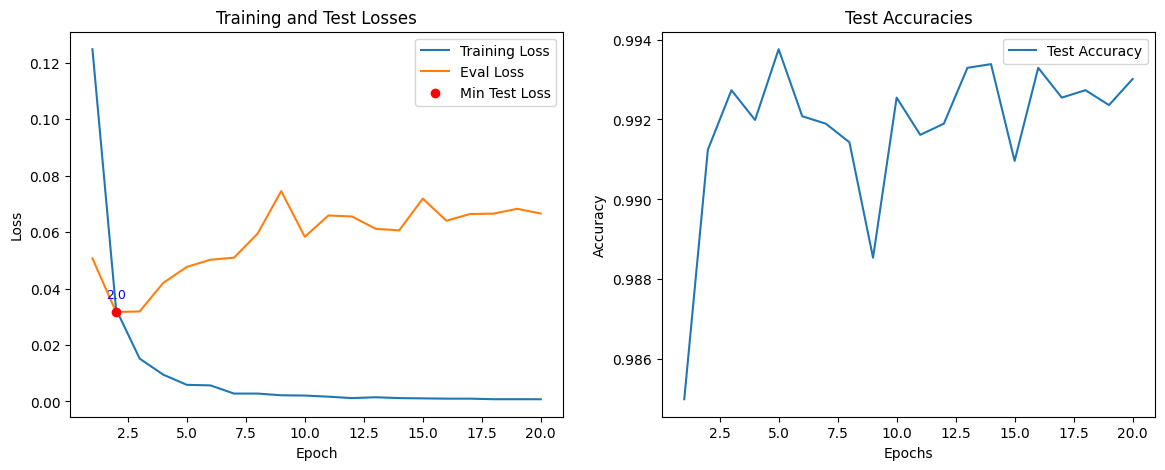

In [29]:
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epoch_num + 1), merged_df['loss'], label='Training Loss')
plt.plot(range(1, epoch_num + 1), merged_df['eval_loss'], label='Eval Loss')
plt.scatter(min_epoch, min_eval_loss, color='red', label='Min Test Loss', zorder=5)
plt.annotate(f'{min_epoch}',
             (min_epoch, min_eval_loss),
             textcoords="offset points",
             xytext=(0,10),
             ha='center',
             color='blue',
             fontsize=9)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Losses")
plt.legend()


# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epoch_num + 1), merged_df['eval_accuracy'], label='Test Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracies')
plt.legend()


plt.show()